In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
from bayexpress_functions import get_BF_21, get_FC, get_BF_k1

from support_dea import (
    prepare_count_matrix,
    sample_overview_data_wrangling,
    gene_ensemble_id_mapping,
)

In [18]:
METADATA_PATH = f"{os.getcwd()}/../../../hgsoc_data_detective/"
DATA_PATH = f"{os.getcwd()}/../../../alignment_results/"
GTF_PATH = (
    f"{os.getcwd()}/../../../../../Downloads/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
)

In [134]:
DATA_TYPE = "Bulk"  # Bulk or Dissociated Bulk

# Load data

In [135]:
sample_df = sample_overview_data_wrangling(METADATA_PATH, DATA_TYPE)

In [136]:
sample_df.head()

,Site of origin,Long Sample ID
Sample #,,
2018,Omentum,230509/2018
2023,Unknown,230509/2023
2094,Unknown,230509/2094
2126,Unknown,230509/2126
2129,Ovary,230509/2129


In [137]:
gtf = gene_ensemble_id_mapping(GTF_PATH)
dict(gtf[:5])

{'ENSG00000287370': 'ENSG00000287370',
 'ENSG00000158955': 'WNT9B',
 'ENSG00000159733': 'ZFYVE28',
 'ENSG00000111371': 'SLC38A1',
 'ENSG00000230250': 'LINC01753'}

# Prepare count matrix

In [138]:
count_matrix = prepare_count_matrix(DATA_PATH)

# Select only bulk / diss bulk samples
if DATA_TYPE == "Bulk":
    count_matrix = count_matrix[~count_matrix.index.str.contains("2304")]
elif DATA_TYPE == "Dissociated Bulk":
    count_matrix = count_matrix[count_matrix.index.str.contains("2304")]

# Add "site of origin" from sample_df
count_matrix.index.name = "Long Sample ID"
count_df = pd.merge(
    sample_df,
    count_matrix,
    how="inner",
    left_on="Long Sample ID",
    right_on="Long Sample ID",
)
count_df = count_df.set_index("Long Sample ID")

In [139]:
# Only consider ovary and omentum samples
count_df = count_df[
    (count_df["Site of origin"] == "Omentum") | (count_df["Site of origin"] == "Ovary")
]

# Only consider genes that have more than 10 read counts in total
count_df = count_df[pd.Index(["Site of origin"]).append(count_df.columns[1:][count_df.iloc[:, 1:].sum(axis=0) >= 10])]

count_df.rename(columns=dict(gtf), inplace=True)

In [140]:
count_df.head()

,Site of origin,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,ENSG00000291297,ENSG00000291299,PRSS30P,LY6S,TMEM276,ENSG00000291326,ENSG00000291342,ADIPINT,ENSG00000292246,ENSG00000292309
Long Sample ID,,,,,,,,,,,,,,,,,,,,,
230509/2018,Omentum,205,2,1629,81,78,615,1159,457,443,...,0,362,21,6,50,7,0,0,1,2
230509/2129,Ovary,221,9,600,84,89,148,1821,233,129,...,0,132,35,4,60,2,0,0,2,0
230509/2186,Omentum,215,6,637,69,52,731,1579,276,941,...,3,205,12,1,70,3,0,1,0,0
230509/2202,Omentum,80,7,1134,40,33,634,2251,344,655,...,0,178,5,2,6,10,0,2,0,9
230509/2444,Omentum,598,8,796,98,82,204,1460,281,224,...,1,203,21,1,7,2,0,1,2,5


In [141]:
omentum_df = count_df[count_df["Site of origin"]=="Omentum"].drop(columns=["Site of origin"]).T

In [142]:
ovary_df = count_df[count_df["Site of origin"]=="Ovary"].drop(columns=["Site of origin"]).T

In [143]:
ovary_df

Long Sample ID,230509/2129,230509/2526,230626/2249,230626/2416,230626/2423
TSPAN6,221,148,587,674,285
TNMD,9,8,8,10,9
DPM1,600,818,2160,3726,2068
SCYL3,84,146,134,236,52
C1orf112,89,61,124,247,45
...,...,...,...,...,...
ENSG00000291326,2,3,17,26,40
ENSG00000291342,0,0,7,0,0
ADIPINT,0,0,6,0,2
ENSG00000292246,2,1,2,1,1


# Calculate Bayes Factor and Log Fold Change

In [144]:
# sum of all reads per gene
n_omentum = omentum_df.sum(axis=1)
n_ovary = ovary_df.sum(axis=1)

In [145]:
# sum of all reads
N_omentum = n_omentum.sum()
N_ovary = n_ovary.sum()

In [146]:
N_omentum, N_ovary

(np.int64(200509021), np.int64(70158070))

In [147]:
# BF_21 compares the two groups (ovary vs omentum)
# FC is the Log2FoldChange
# BF_k1_omentum compares samples in the group omentum
# BF_k1_ovary compares samples in the group ovary
df = pd.DataFrame(
    {
        "BF_21": get_BF_21(N_omentum, n_omentum, N_ovary, n_ovary),
        "FC": get_FC(N_omentum, n_omentum, N_ovary, n_ovary),
        "BF_k1_omentum": get_BF_k1(omentum_df),
        "BF_k1_ovary": get_BF_k1(ovary_df),
    }
)

## Interpretation

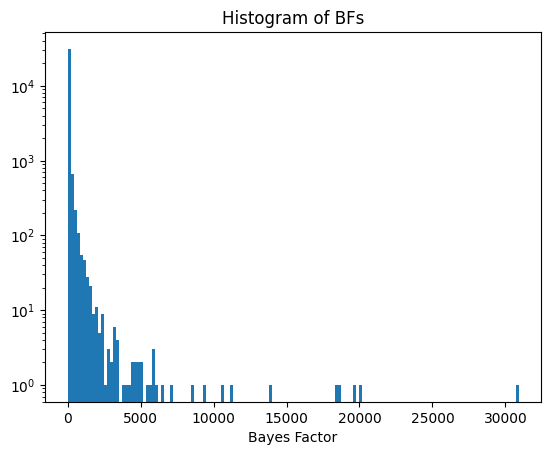

In [148]:
# Distribution of Bayes Factors (BFs)
fig, ax = plt.subplots()
ax.hist(df["BF_21"], bins=150)
ax.set_yscale("log")
ax.set_xlabel("Bayes Factor")
ax.set_title("Histogram of BFs")

plt.show()

In [149]:
df.sort_values(by="BF_21", ascending=False)

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
MUC16,30902.901985,-1.211690,182757.098175,29975.218027
FOSB,20094.759406,0.822316,27462.330618,19995.814408
CLU,19650.227751,-1.630101,112397.545956,3383.704190
IGFBP5,18669.283667,1.828151,8551.985177,11545.946017
MEG3,18337.320576,2.259282,10499.517847,12291.736684
...,...,...,...,...
ENSG00000276403,-7.153861,-0.069976,-73.554319,-25.912519
LINC00681,-7.153861,-0.069976,-69.827822,-25.970011
LINC01100,-7.153861,-0.069976,-71.555334,-25.970011
ENSG00000272545,-7.153861,-0.069976,-72.417701,-26.087115


In [150]:
# BF < 0: no change in gene expression
len(df[df["BF_21"]<0])

20336

In [151]:
# BF > 0: change in gene expression
len(df[df["BF_21"]>0])

11936

In [152]:
# In the paper they choose BF > 1 as a cut-off
df[df["BF_21"]>1].sort_values("BF_21", ascending=False)

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
MUC16,30902.901985,-1.211690,182757.098175,29975.218027
FOSB,20094.759406,0.822316,27462.330618,19995.814408
CLU,19650.227751,-1.630101,112397.545956,3383.704190
IGFBP5,18669.283667,1.828151,8551.985177,11545.946017
MEG3,18337.320576,2.259282,10499.517847,12291.736684
...,...,...,...,...
FAM215B,1.004975,-1.436105,-55.240545,-23.428860
TAFAZZIN,1.003044,-0.253768,18.837270,12.943847
FOSL2-AS1,1.002224,0.251239,149.650806,48.959349
COPS7B,1.001206,-0.213579,87.204453,71.060381


In [153]:
# Let's compare it to our pydeseq2 analysis
# Using the same LogFoldChange cut-off and using BF to assess significantly DE genes
df[(abs(df["FC"])>0.5)&(df["BF_21"]>1)].sort_values("BF_21", ascending=False).head(10)

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
MUC16,30902.901985,-1.211690,182757.098175,29975.218027
FOSB,20094.759406,0.822316,27462.330618,19995.814408
CLU,19650.227751,-1.630101,112397.545956,3383.704190
IGFBP5,18669.283667,1.828151,8551.985177,11545.946017
MEG3,18337.320576,2.259282,10499.517847,12291.736684
CD74,13995.271689,-1.335208,21981.926121,3517.499642
COL1A1,11140.141770,-0.636199,95237.232261,6231.458213
C3,10553.300994,-1.126179,26821.686935,6681.404432
STAR,9285.437802,4.868808,1913.174859,7161.077393
GREB1,8507.876459,3.073205,5338.905161,6382.548474


### Dissociated bulk

Note I reran the above analysis with the appropriate DATA_TYPE for the Dissociated bulk and Bulk sections.

In [117]:
# Let's compare the top 10 genes in each approach

# For dissociated bulk, pydeseq2 only yielded 9 DE genes
comp_diss_bulk_genes = [
    "CILP",
    "IGF2",
    "MEFV",
    "C9orf72",
    "P2RY14",
    "GLIS3-AS1",
    "LINC02940",
    "IGF2-AS",
    "ENSG00000289074",
]

In [118]:
# These are considered significantly DE here too, but some of them don't stand out as much.
df.loc[comp_diss_bulk_genes]

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
CILP,1678.646770,-3.123576,2043.687443,13.992071
IGF2,9252.946024,-4.366387,16153.628540,62.112576
MEFV,300.809008,3.342019,-40.800076,369.220538
C9orf72,550.100088,1.508125,12.199485,405.937905
P2RY14,47.295961,2.206052,-43.955159,-15.512673
GLIS3-AS1,106.917537,5.106456,-58.416429,122.035349
LINC02940,60.002062,1.649343,-42.264754,4.598968
IGF2-AS,43.598582,-4.989684,47.710985,-26.128375
ENSG00000289074,15.953269,-1.730638,-41.873957,-21.878104


In [119]:
# Which genes are in the top 10 for both approaches?
# Only IGF2
# In fact, even in the top 50, only IGF2 is seen both lists.

### Bulk

In [157]:
comp_bulk_genes = list(pd.read_csv("../results/de_genes_bulk_rrna-.csv", index_col=0).index)

In [158]:
comp_bulk_genes[:5]

['STAR', 'LINC01391', 'PCDH11X', 'MELTF', 'PCSK6']

In [240]:
len(comp_bulk_genes)

148

In [241]:
# All DE genes from pydeseq2 are identified by both methods
len(set(df.index)&set(comp_bulk_genes))

148

In [253]:
# Let's compare the top 10
# Only STAR overlaps
# Top 50: STAR and PEG3 overlap
set(comp_bulk_genes[:50])&set(df.sort_values(by="BF_21", ascending=False).index[:50])

{'PEG3', 'STAR'}

### Adipocyte markers

Just having a look, but nothing is significantly DE.

In [159]:
df[df.index.str.contains("ADIPOQ")]

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
ADIPOQ,-4.309094,-1.244006,-37.188196,-22.562625


In [160]:
df[df.index.str.contains("PLIN1")]

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
PLIN1,-6.221083,-0.188621,-32.09508,-21.040212


In [161]:
df[df.index.str.contains("CIDEC")]

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
CIDEC,-4.156385,-2.292369,-64.162718,-26.087115


Some open questions / thoughts:

I am not sure how the total number of samples (ovary + omentum) is affecting this analysis.

I am also not sure how the asymmetry in the number of samples (ovary 5-7, omentum 10) is affecting the analysis.

## Q plots

In [123]:
omentum_q = pd.DataFrame()

for col in omentum_df.columns:
    omentum_q[col] = (omentum_df[col] + 1) / (sum(omentum_df[col])+2)

In [124]:
ovary_q = pd.DataFrame()

for col in ovary_df.columns:
    ovary_q[col] = (ovary_df[col] + 1) / (sum(ovary_df[col])+2)

In [125]:
def q_plot(exp_1, exp_2):

    # printing q-plots
    for t in range(len(exp_1)):
        fig, ax = plt.subplots(figsize=(8, 6))

        # histogram Exp 1
        ax.hist(exp_1.iloc[t], 10, density=False, histtype='step', color='#332288',
                alpha=0.4, orientation='horizontal')

        # histogram Exp 2
        ax.hist(exp_2.iloc[t], 10, density=False, histtype='step', color='#DDCC77',
                alpha=0.4, orientation='horizontal')


        # scatter Exp 1
        ax.scatter(np.arange(1,len(exp_1.columns)+1), exp_1.iloc[t],
                
            c='#332288', s=30, 
            label='Omentum',
            alpha=0.9, edgecolors='none')
        
        # scatter Exp 2
        ax.scatter(np.arange(1,len(exp_2.columns)+1), exp_2.iloc[t],
                
            c='#DDCC77', s=30, 
            label='Ovary',
            alpha=0.9, edgecolors='none')
        
        ax.legend(loc='upper right')

        # Use tex in labels
        ax.set_xticks(np.arange(1,len(exp_1.columns)+1))
        ax.set_xticklabels('')

        # formatting y axis ticks
        plt.gca().ticklabel_format(axis='y', style='plain', useOffset=False)

        ax.set_xlabel('Replicates')
        ax.set_ylabel('q = (n+1) / (N+2)')
        ax.set_title(f"{exp_1.iloc[t].name}")

        plt.show()

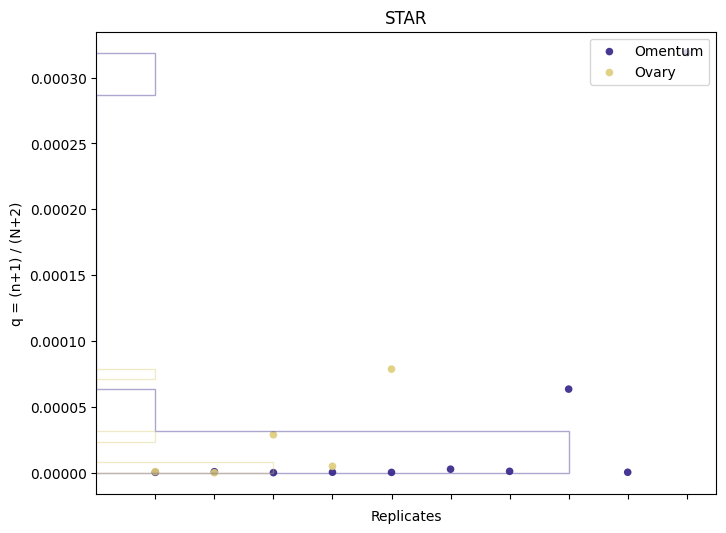

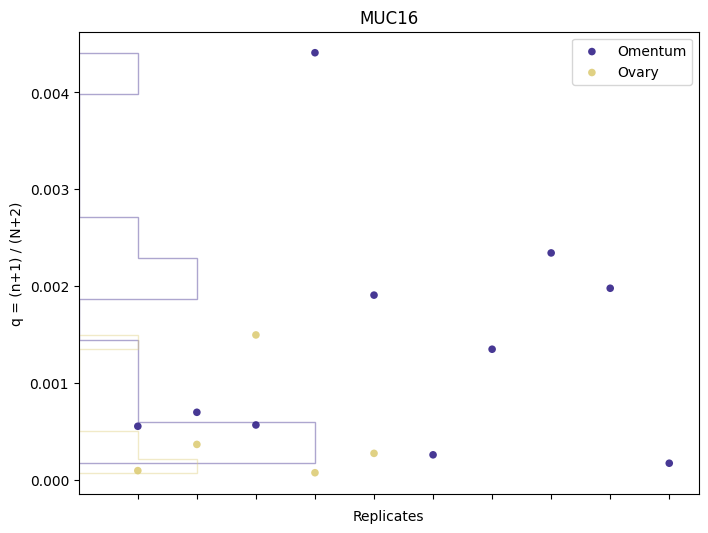

In [126]:
# I am not loving these plots.
# They'd probably be more helpful if we had more samples.
genes = ["STAR", "MUC16"]
q_plot(omentum_q.loc[genes], ovary_q.loc[genes])

## "Volcano" plot

In [162]:
adipocyte_markers_df = pd.read_excel("../data/emont2022s1.xlsx", sheet_name="adipocyte markers", header=1).set_index("Unnamed: 0")
adipocyte_markers_df.index.name = None

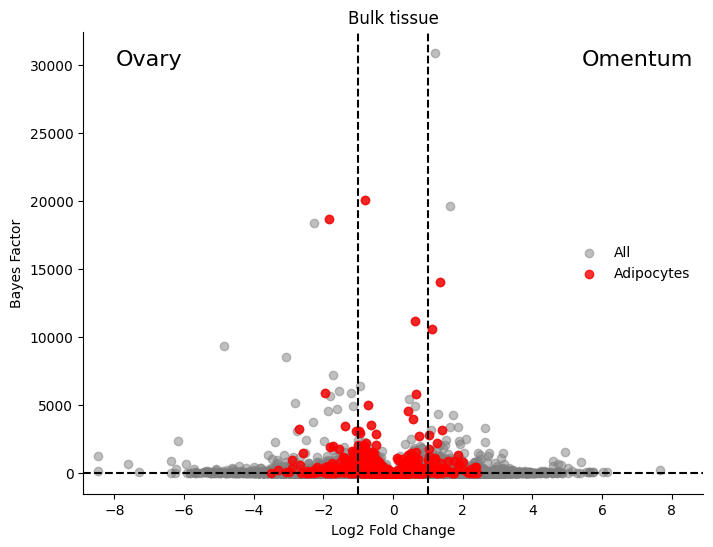

In [166]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    -df["FC"], 
    df["BF_21"],
    c="grey",
    label="All",
    alpha=0.5
)

# # Plot adipocyte genes
plt.scatter(
    -df[df.index.isin(list(adipocyte_markers_df.index))]["FC"],
    df[df.index.isin(list(adipocyte_markers_df.index))]["BF_21"],
    c='red', 
    label='Adipocytes', 
    alpha=0.8
)

x_lim = abs(df["FC"]).max()*1.05
plt.xlim([-x_lim, x_lim])

# # Add vertical lines for fold change threshold (optional)
plt.axvline(x=-1, color='black', linestyle='--')
plt.axvline(x=1, color='black', linestyle='--')

# # Add horizontal line for significance threshold
plt.axhline(y=1, color='black', linestyle='--')

plt.xlabel('Log2 Fold Change')
plt.ylabel('Bayes Factor')
plt.title(f"{DATA_TYPE} tissue")

plt.legend(frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.text(-7, 30000, "Ovary", size=16, ha="center")
plt.text(7, 30000, "Omentum", size=16, ha="center")

plt.show()

In [164]:
filename = f"../results/figures/volcano_plot_bayexpress_{DATA_TYPE}"
fig.savefig(filename + ".png", bbox_inches="tight")
fig.savefig(filename + ".pdf", bbox_inches="tight")

In [165]:
df.sort_values(by="BF_21", ascending=False).to_csv(f"../results/de_genes_bayexpress_{DATA_TYPE}.csv", index=True)